# Gradient boosting with regression stumps

Gradient boosting builds an additive model in stages. It begins with a simple prediction, fits a weak learner to the remaining error, and adds a scaled version of that learner to the current model.


## Residuals and the negative gradient

For squared error, the negative gradient with respect to the current prediction is

```text
residual = y - prediction
```

This is why fitting the next learner to residuals is a gradient step in function space.


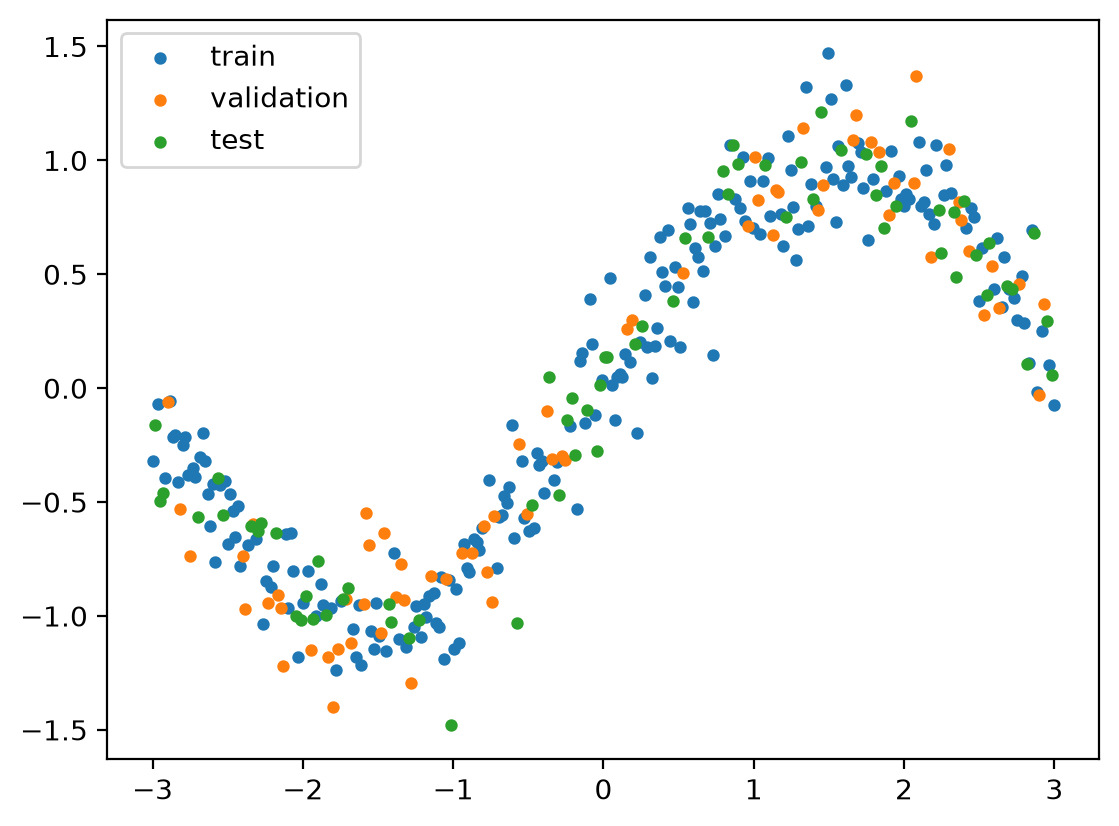

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(72)
x = np.linspace(-3, 3, 360)
y = np.sin(x) + rng.normal(0, 0.18, size=len(x))

order = rng.permutation(len(x))
train_idx, val_idx, test_idx = order[:220], order[220:290], order[290:]
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]
x_test, y_test = x[test_idx], y[test_idx]

plt.scatter(x_train, y_train, s=12, label='train')
plt.scatter(x_val, y_val, s=12, label='validation')
plt.scatter(x_test, y_test, s=12, label='test')
plt.legend()
plt.show()

## Regression stumps

A stump selects one threshold and predicts a constant residual on either side. The code checks candidate thresholds and chooses the one that minimizes the squared residual error. A single stump is weak; a sequence of stumps can represent a more complicated function.


In [2]:
def fit_stump(x, residuals, min_samples=3):
    values = np.unique(x)
    thresholds = (values[:-1] + values[1:]) / 2
    best = None

    for threshold in thresholds:
        left = x <= threshold
        right = ~left
        if left.sum() < min_samples or right.sum() < min_samples:
            continue
        left_value = residuals[left].mean()
        right_value = residuals[right].mean()
        error = ((residuals[left] - left_value) ** 2).sum()
        error += ((residuals[right] - right_value) ** 2).sum()
        candidate = (error, threshold, left_value, right_value)
        if best is None or candidate[0] < best[0]:
            best = candidate

    if best is None:
        raise ValueError('no valid stump split')
    return best[1:]

def stump_predict(x, stump):
    threshold, left_value, right_value = stump
    return np.where(x <= threshold, left_value, right_value)

## Additive updates

```text
F_0(x) = mean(y_train)
F_m(x) = F_(m-1)(x) + learning_rate * stump_m(x)
```

The learning rate controls the size of each correction. The training error usually decreases as rounds are added, but validation error can increase once the ensemble begins fitting noise.


for learning rate 0.1, validation selects 199 rounds


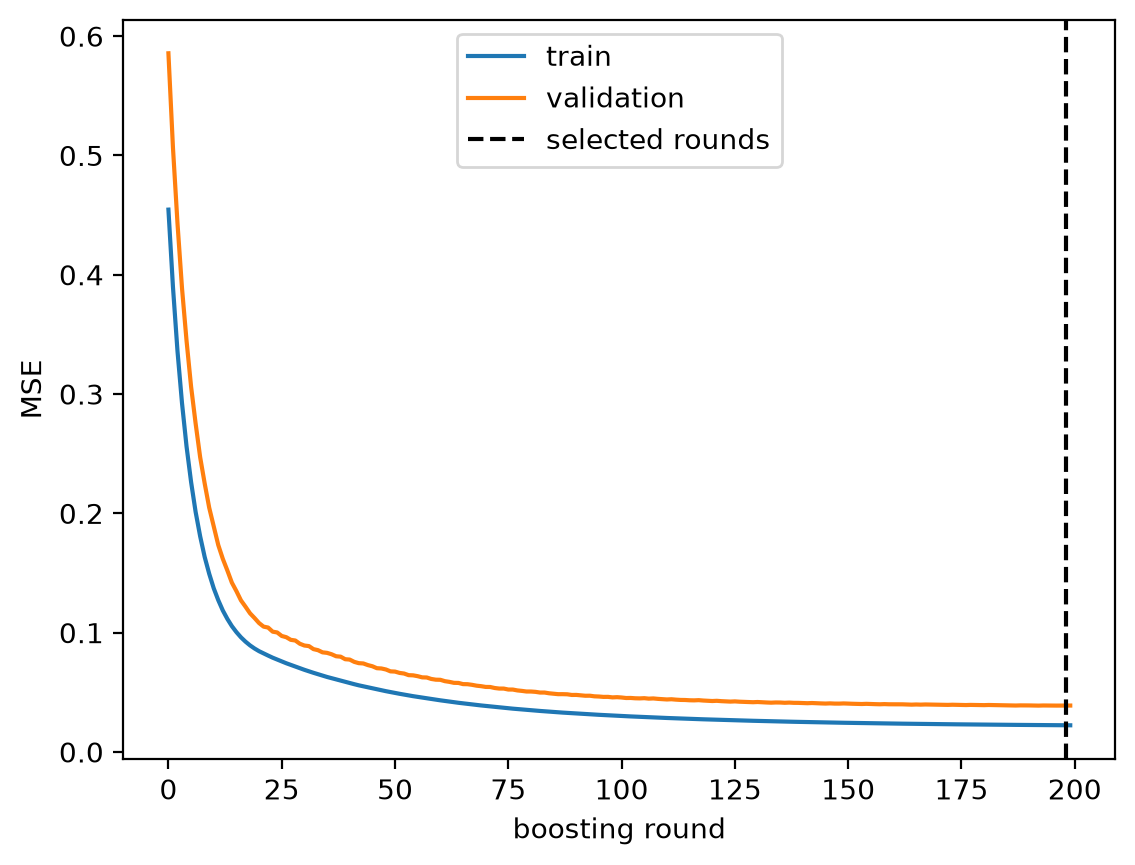

In [3]:
def fit_boosting(x, y, rounds=200, learning_rate=0.1):
    base = y.mean()
    prediction = np.full(len(y), base)
    stumps, train_mse = [], []
    for _ in range(rounds):
        stump = fit_stump(x, y - prediction)
        prediction += learning_rate * stump_predict(x, stump)
        stumps.append(stump)
        train_mse.append(np.mean((y - prediction) ** 2))
    return base, stumps, np.array(train_mse)

def predict_boosting(x, base, stumps, learning_rate):
    prediction = np.full(len(x), base)
    for stump in stumps:
        prediction += learning_rate * stump_predict(x, stump)
    return prediction

base, stumps, train_mse = fit_boosting(x_train, y_train, rounds=200, learning_rate=0.1)
validation_mse = [np.mean((y_val - predict_boosting(x_val, base, stumps[:n], 0.1)) ** 2) for n in range(1, len(stumps) + 1)]
best_round = int(np.argmin(validation_mse)) + 1
print(f'for learning rate 0.1, validation selects {best_round} rounds')
plt.plot(train_mse, label='train')
plt.plot(validation_mse, label='validation')
plt.axvline(best_round - 1, linestyle='--', color='black', label='selected rounds')
plt.xlabel('boosting round')
plt.ylabel('MSE')
plt.legend()
plt.show()


## Selecting rounds and learning rate

For each learning rate, validation MSE selects the number of rounds. The best rate and round count are then fixed before the single test evaluation. A small learning rate generally requires more rounds; a large one gives each stump a stronger effect.


learning rate=0.03: best validation MSE=0.0621 at round 200


learning rate=0.10: best validation MSE=0.0388 at round 199


learning rate=0.30: best validation MSE=0.0389 at round 68

selected configuration: rate=0.10, rounds=199
one final test MSE: 0.0348


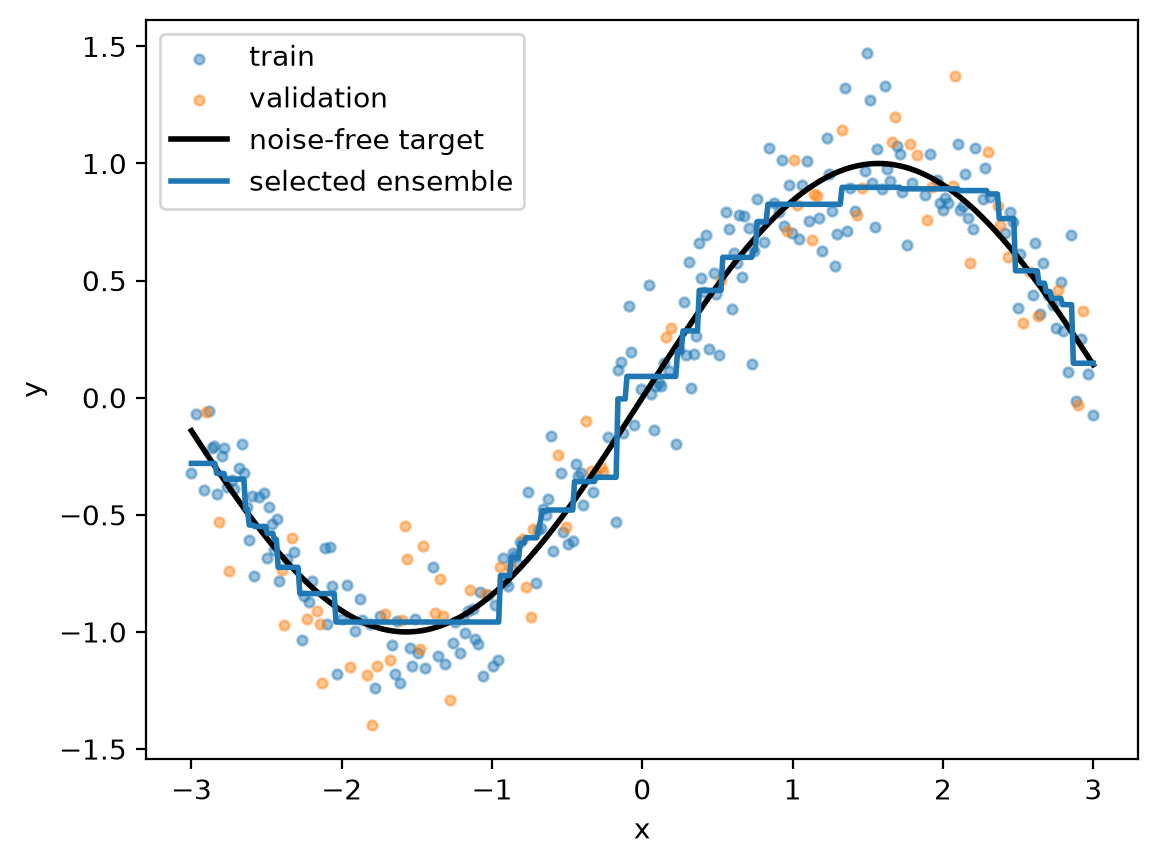

In [4]:
candidate_rates = [0.03, 0.1, 0.3]
configurations = []
for learning_rate in candidate_rates:
    base_lr, stumps_lr, _ = fit_boosting(x_train, y_train, rounds=200, learning_rate=learning_rate)
    curve = [np.mean((y_val - predict_boosting(x_val, base_lr, stumps_lr[:n], learning_rate)) ** 2) for n in range(1, 201)]
    selected_round = int(np.argmin(curve)) + 1
    configurations.append((min(curve), learning_rate, selected_round, base_lr, stumps_lr))
    print(f'learning rate={learning_rate:.2f}: best validation MSE={min(curve):.4f} at round {selected_round}')

_, selected_rate, selected_round, selected_base, selected_stumps = min(configurations, key=lambda item: item[0])
test_prediction = predict_boosting(x_test, selected_base, selected_stumps[:selected_round], selected_rate)
print()
print(f'selected configuration: rate={selected_rate:.2f}, rounds={selected_round}')
print(f'one final test MSE: {np.mean((y_test - test_prediction) ** 2):.4f}')

grid = np.linspace(-3, 3, 500)
grid_prediction = predict_boosting(grid, selected_base, selected_stumps[:selected_round], selected_rate)
plt.scatter(x_train, y_train, s=12, alpha=0.45, label='train')
plt.scatter(x_val, y_val, s=12, alpha=0.45, label='validation')
plt.plot(grid, np.sin(grid), color='black', linewidth=2, label='noise-free target')
plt.plot(grid, grid_prediction, color='tab:blue', linewidth=2, label='selected ensemble')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()


## Final fit

The selected ensemble is plotted against the training and validation observations and the noise-free sine function used to generate the data. The plot shows both the fitted function and the residual-driven construction behind it.
